## Predictive Bank Marketing Analysis

------
------

## Project Summary

This project analyzes customer behavior from a real-world bank marketing campaign to identify which factors influence term deposit subscriptions.

---

### Key Findings

- Prior campaign success and customer balance are strong indicators of subscription likelihood  
- Excessive outreach appears less effective than targeted communication  
- Job type, education level, and contact method show meaningful differences in conversion behavior  

---

### Model Result

- Logistic Regression achieved approximately 81% accuracy

---

### Business Value

- Translates customer data into targeting recommendations  
- Helps improve campaign efficiency and reduce wasted outreach  



-----
------

## Objective:

The goal of this project is to predict whether a customer will subscribe to a term deposit and identify the variables that most influence that decision.

I focus on building an interpretable analysis that connects customer behavior, campaign strategy, and business decision-making.

------
------

## Dataset Overview & Loading:

### Dataset Context

This dataset comes from a real-world bank marketing campaign and contains customer demographic and interaction data.

### Business Problem

The objective is to predict whether a customer will subscribe to a term deposit and identify which factors drive conversion.

This problem is relevant in financial services, where improving targeting efficiency can directly impact profitability and resource allocation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


-----

### Initial Data Preview

In [9]:
df = pd.read_csv("../data/bank-full.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


The dataset loads successfully and shows a mix of demographic and campaign-related features, with each row representing a customer interaction.

-----
--------

## Exploritory Data Analysis:

### Dataset Size

In [10]:
df.shape
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

The dataset contains **11,162 observations across 17 features**, providing a solid sample size for identifying meaningful patterns in customer behavior.

--------

### Missing Values

In [4]:
df.isnull().sum()

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit    0
dtype: int64

No missing values are present in the dataset.

This simplifies preprocessing and allows the analysis to focus directly on pattern discovery rather than data cleaning.

---

### Target Distribution

In [6]:
df.columns

Index(['age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit'], dtype='object')

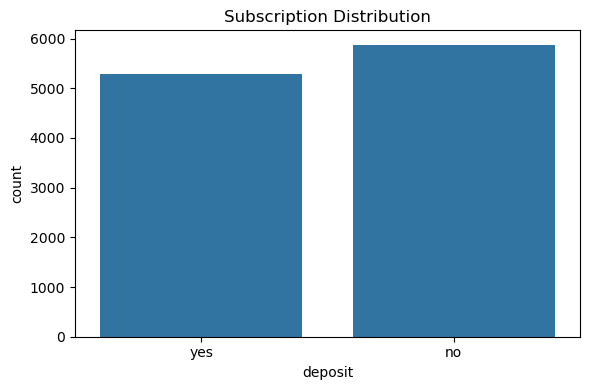

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='deposit')
plt.title('Subscription Distribution')

plt.tight_layout()
plt.show()

The dataset shows a relatively balanced distribution between subscribed and non-subscribed customers, though slightly more customers did not subscribe.

This indicates the classification problem is **not heavily imbalanced**, which is beneficial for model performance.

-------


### Conversion by Job Role

In [ ]:
job_rate = df.groupby('job')['deposit'].value_counts(normalize=True).unstack()
job_rate

deposit,no,yes
job,,
admin.,0.526987,0.473013
blue-collar,0.635802,0.364198
entrepreneur,0.625000,0.375000
housemaid,0.602190,0.397810
management,0.492985,0.507015
retired,0.336761,0.663239
self-employed,0.538272,0.461728
services,0.600217,0.399783
student,0.252778,0.747222


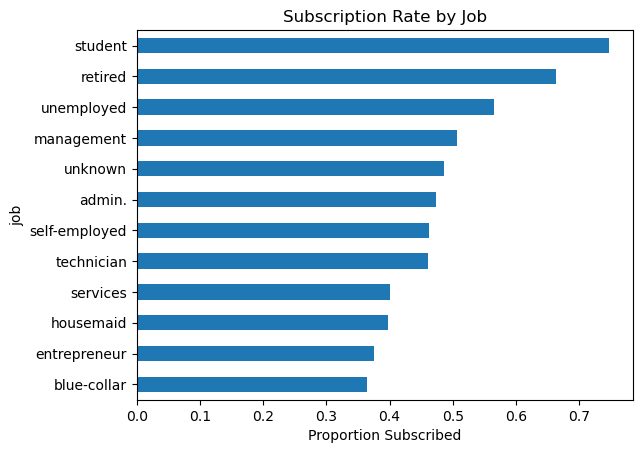

In [ ]:
## Visual

job_rate = df.groupby('job')['deposit'].value_counts(normalize=True).unstack()

job_rate['yes'].sort_values().plot(kind='barh')
plt.title('Subscription Rate by Job')
plt.xlabel('Proportion Subscribed')
plt.show()

Insight: Subscription rates vary meaningfully across job categories.

Interpretation: Customer occupation appears to influence responsiveness to marketing campaigns.


------

### Conversion by Education Level

In [ ]:
edu_rate = df.groupby('education')['deposit'].value_counts(normalize=True).unstack()
edu_rate

deposit,no,yes
education,,
primary,0.606000,0.394000
secondary,0.552593,0.447407
tertiary,0.458932,0.541068
unknown,0.492958,0.507042


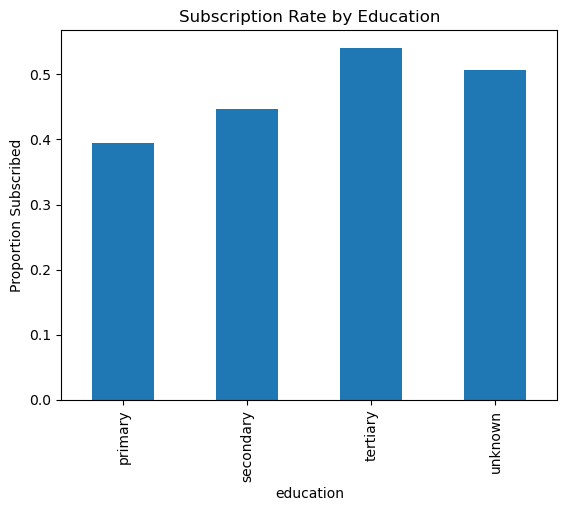

In [ ]:
edu_rate['yes'].plot(kind='bar')
plt.title('Subscription Rate by Education')
plt.ylabel('Proportion Subscribed')
plt.show()

 Insight: helps identify whether financial literacy or education background may influence customer decisions.

 Interpretation: Education level may correlate with financial awareness and decision-making. This suggests a more value-focused messaging for highly educated customers 


-----

### Numerical Feature Comparison

In [ ]:
df.groupby('deposit')[['age', 'balance', 'campaign', 'pdays', 'previous']].mean()

,age,balance,campaign,pdays,previous
deposit,,,,,
no,40.837391,1280.227141,2.839264,35.685340,0.528350
yes,41.670070,1804.267915,2.141047,68.702968,1.170354


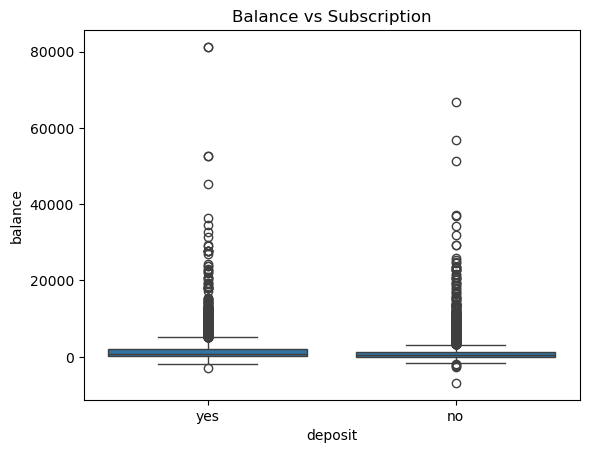

In [ ]:
sns.boxplot(x='deposit', y='balance', data=df)
plt.title('Balance vs Subscription')
plt.show()

Insight: 
-This table helps identify behavioral and financial differences between the two groups by comparing average numerical values between customers who subscribed and those who did not.

-These results suggest customers who subscribe generally have higher account balances, though there is overlap between the groups.

-Outliers are present, but the overall trend supports the difference in financial capacity.

Interpretation: This is helpful to businesses when recognizing patterns which also suggest possible Financial capacity (balance) is a strong driver of conversion. 



--------
------

## Modeling:

I use a Logistic Regression as a baseline classification model to predict wether a customer will subscribe to a term deposit. 

This model was chosen because: It is interpretable, Performs well on binary classification problems, allows us to understand how features influence outcomes.

----



### Data Preparation

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('deposit_yes', axis=1)
y = df_encoded['deposit_yes']

One-hot encoding is used here to convert categorical variables into a numeric format. Allowing the model to interpret non-numeric features such as a job, education, and contact type.

------

### Train-Test Split


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Dataset split into training (80%) and testing (20%) sets, ensuring the model is evaluated on unseen data, allowing us to measure how well it generalizes rather than pattern recognition. 

--------

### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Numerical features are standardized using a StandardScaler.

This is helpful considering Logistic Regression performs better when features are on a similar scale, preventing variables with larger magnitudes to dominate the model.


--------

### Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

The Logistic Regression model is trained on the scaled training data.

The model learns relationships between customer features and the likelihood of subscription.

--------

### Model Performance

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8083296014330497

Insight: The model achieved an accuracy of approximately **80.8%** on the test dataset.

Interpretation: Model correctly predicts whether a customer subscribes about 8 out of 10 times.

While accuracy provides a useful overall measure, it does not fully capture the types of errors the model makes.


-------

### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[972, 194],
       [234, 833]])

- **True Negatives (972):** Correctly predicted non-subscribers  
- **True Positives (833):** Correctly predicted subscribers  
- **False Positives (194):** Incorrectly predicted subscription  
- **False Negatives (234):** Missed actual subscribers  

Insight:
 The model performs well overall, but it misses some customers who would have subscribed.

Interpretation:
- **False Negatives (missed subscribers)** → Lost revenue opportunities  
- **False Positives (incorrect targeting)** → Wasted marketing effort  

Depending on business priorities, the model could be adjusted to:
- Capture more potential subscribers (recall focus)
- Or reduce unnecessary outreach (precision focus)

-------

## Modeling Summary

- Logistic Regression achieved strong baseline performance (~81% accuracy)
- Customer financial behavior and prior interactions are key predictive signals
- The model is effective but can be further improved with:
  - Hyperparameter tuning
  - Feature engineering
  - More advanced models (e.g., Random Forest, Gradient Boosting)

Overall, the model provides a solid foundation for predicting customer conversion and supporting data-driven marketing decisions.

---------
-------

## Feature Importance (Model Interpretation):
 ---------
 ---------

In order to distinguish what drives customer subscription behavior, I will examine the coefficients of the Logisic Regression model.

Positive value indicates variables that increase the likelihood of subscriptions, while negative values
 decrease it. 

 ------



### Top Positive Drivers of Subscription

In [ ]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,


    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False).head(10)



,Feature,Coefficient
3,duration,1.916184
40,poutcome_success,0.648274
34,month_mar,0.295705
21,education_tertiary,0.240892
37,month_oct,0.207223
38,month_sep,0.188732
29,month_dec,0.157809
20,education_secondary,0.120083
33,month_jun,0.116905
1,balance,0.069943


Insight:

 - **Call duration** is the most dominant factor, suggesting that longer conversations significantly increase conversion probability.
- **Previous campaign success (poutcome_success)** strongly boosts likelihood, indicating that past positive interactions are highly predictive.
- **Seasonality effects (March, October, September)** suggest timing plays a role in campaign effectiveness.
- **Higher education levels (tertiary)** show increased likelihood of subscription, potentially reflecting greater financial awareness.
- **Account balance** has a smaller but positive effect, supporting the idea that financial capacity influences decisions.

Interpretation:

These features highlight that **engagement quality and prior experience** are the strongest drivers of customer behavior.



**It is important to note that the strong impact of call duration may reflect information gained during the call rather than a causal driver, and should be interpreted carefully in a real-world setting.

### Key Negative Drivers of Subscription

In [ ]:
coefficients.sort_values(by='Coefficient', ascending=True).head(10)

,Feature,Coefficient
27,contact_unknown,-0.658943
24,housing_yes,-0.344953
32,month_jul,-0.324294
28,month_aug,-0.284477
36,month_nov,-0.278493
35,month_may,-0.276565
4,campaign,-0.245342
31,month_jan,-0.201076
25,loan_yes,-0.165169
41,poutcome_unknown,-0.150847


Insight: 

-**Unknown contact type (contact_unknown)** strongly reduces conversion, suggesting poor data quality or less effective communication channels.

-Customers with **housing loans or personal loans** are less likely to subscribe, likely due to financial constraints or competing obligations.

-Higher **campaign contact frequency** negatively impacts conversion, indicating that excessive outreach may reduce effectiveness.

-Certain months (January, May, July, August, November) show lower conversion rates, suggesting less optimal campaign timing.

-**Unknown previous outcomes (poutcome_unknown)** reduce likelihood, reinforcing the importance of prior engagement history.

These results suggest that **inefficient targeting, poor data quality, and over-contacting customers** can significantly reduce campaign effectiveness.

Interpretation: 

Together, these features highlight that avoiding overexposure and improving customer data quality are critical for maximizing marketing performance.

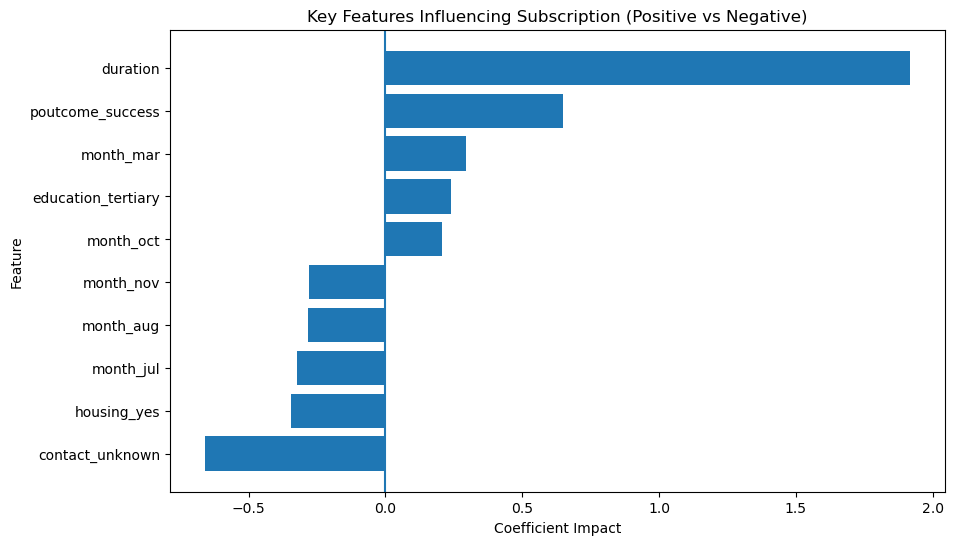

In [ ]:
## Visual 

top_positive = coefficients.sort_values(by='Coefficient', ascending=False).head(5)
top_negative = coefficients.sort_values(by='Coefficient', ascending=True).head(5)

combined = pd.concat([top_positive, top_negative])

# Sort so negatives appear on bottom, positives on top
combined = combined.sort_values(by='Coefficient')

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(combined['Feature'], combined['Coefficient'])
plt.axvline(0)  # separates positive vs negative

plt.title('Key Features Influencing Subscription (Positive vs Negative)')
plt.xlabel('Coefficient Impact')
plt.ylabel('Feature')

plt.show()

This visualization helps to explain the contrast between features that drive customer subscription and those that hinder it, providing a clear targeted marketing strategy.

-----
------

## Final Insights & Business Recomendations:
-----
-----

Based on the model resutls and feature importance analysis, I've discovered actionable insights that can improve marketing effectiveness and customer conversion rates. 

-----


## 1. Which Customers to Target? 
Results show that variable `poutcome_success` is one of the strongest positive predictors of subscription.

This suggests that customers who have previously responded positively to campaigns are significantly more likely to convert again. 

Recomended Action: 
-Build targeted campaigns specifically for customers with prior successful interactions
-allocate a higher portion of marketing budget toward this segment.
-Use personalized messaging refrencing past engagement

Philisophical Application: 
"Focus marketing budget on these high-probability segments"





-------------
## 2. What Drives Conversion?

The variable `campaign` (number of contacts) shows a negative relationship with subscription liklihood.

This suggests that repeatedly contacting customers may reduce effectiveness and lead to diminishing returns.

Recomended Action: 
-Limit number of outreach attempts per customer
-Focus on quality of interaction rather than frequency 
-Implement contact caps to prevent customer fatigue


Philisophical Application: 
"Prioritize quality interactions over quantity"


-------
## 3. Risk Segements?
-Blue-collar and entrepreneur segments underperform
-Certain months show consistently lower engagement


Philisophical Application: 
"Rework messaging or reduce spend in these areas"

----

## 4. How Financial Indicators Influence Behavior?

-Variables such as `balance` show a positive relationship with subscription likelihood.

-This suggests that customers with stronger financial positions are more likely to invest in term deposits.

Recomended Action: 
-Segment customers based on financial indicators
-Target higher-balance customers with premium or long-term deposit offering

------

## Final Insight

This model demonstrates that customer behavior is not random-subscription likelihood is strongly influenced by prior engagement, financial position, contact strategy, and timing.

By focusing on high-probability segements and eliminating inefficient outreach, marketing campaigns can become significantly more cost-effective and conversion-driven.

------
-------